# Blockchain–AI Governance Evaluation: Frozen V1.1 Evidence Synthesis and Thesis Presentation

**Repository:** `PhD-Blockchain-AI`  ·  **Stage:** V1.1-G2 (thesis-ready notebook)  ·  **Analysis mode:** `DESCRIPTIVE_ONLY`

> **Scope declaration.** The governed study `V1.1-A → V1.1-F` (protocols, engine,
> real-order mapping, governed AI-risk generation, E01–E10 experiments, and read-only
> synthesis) is **already completed**. This notebook is a **read-only scientific
> synthesis** of the frozen, persisted evidence. It executes **no new experiment**,
> trains **no model**, performs **no AI inference**, and measures **no new benchmark**.
> Every figure and table below is reconstructed from locked artifacts under
> `results/blockchain/v11e/`, `results/blockchain/v11f/`, `config/`, and `docs/`.
>
> **Energy status:** `DIRECT_ENERGY_UNAVAILABLE`. No timing, memory, storage, or
> throughput value in this notebook is a measured physical-energy quantity, and no
> Joules/Watts/Wh/CO₂e/TDP-time inference is made anywhere.

# 1. Research Context and Objective

## 1.1 Context

Modern supply chains generate large order-level event histories that must be both
**traceable** and **verifiable**. The governed `V1.1` study explores a lightweight,
deterministic, **per-order hash-linked ledger** ("blockchain-inspired integrity layer",
not a mining network) inside which a frozen **AI-generated risk record** participates.

The challenge is a two-sided evaluation:

1. **Security.** Can the integrity layer detect and localize controlled tampering of
   order records when a validation policy inspects it?
2. **Efficiency.** How much computational "weight" does each validation policy add,
   measured with persisted descriptive computational/resource proxies under a strict
   `DIRECT_ENERGY_UNAVAILABLE` constraint?

## 1.2 Objective of this notebook

The notebook presents the frozen `V1.1` evidence chain end-to-end:

- the framework architecture (Section 4) and the implemented blockchain mechanism
  (Section 5);
- the governance of the study and its frozen integrity gates (Section 2);
- the AI/risk integration and the governed population (Sections 6–7);
- the governed tampering scenario set `PA-01 … PA-09` (Section 8);
- the `E01–E10` experimental map and each experiment's descriptive evidence
  (Sections 9–18);
- the endpoint-specific security–resource trade-off, green-oriented interpretation,
  limitations, reproducibility, and thesis-ready conclusions (Sections 19–23).

All claims are **descriptive** and **endpoint-specific**. No policy is declared
"best", "winner", "optimal", "superior", or "recommended", and no overall ranking,
composite score, or weight is computed.

# 2. V1.1 Experimental Governance

## 2.1 Frozen governance model

Every `V1.1` stage is one commit with a matching trio
(`src/` orchestrator + `tests/` + artifacts under `results/<stage>/`) and pinned
protocol configs in `config/*.yaml`. Pipelines are **HEAD-guarded** and execute only
at their authorized commit; the notebook never executes a pipeline.

## 2.2 Read-only boundary (this notebook)

| Dimension | Policy |
|---|---|
| Experiment execution | Forbidden — consumed artifacts are frozen |
| AI fit / inference | Forbidden — counts are required to be zero |
| TEST-split evaluation | Forbidden (`no TestSplit`) |
| New timing/memory/storage/throughput measurement | Forbidden |
| Policy tuning / selection | Forbidden |
| Winner / ranking / composite score | Forbidden |
| Frozen artifact mutation | Forbidden — verified byte-identical |
| Statistical inference | Forbidden — descriptive summaries only |

## 2.3 Fail-closed integrity gate

The next cell verifies **before any scientific presentation**:

- the repository commit equals `a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981` (HEAD == origin/main);
- the F2/F4/F5 and V1.1-E frozen hashes;
- `validation_gates_all == true`;
- the governed invariants (policies, workloads, seeds, population, cell counts,
  E02 detection counts, E04 preservation).

If any check fails the cell raises and **stops** the notebook (`FAIL CLOSED`).

In [1]:
import hashlib, json, os, subprocess, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown, HTML

get_ipython().run_line_magic("matplotlib", "inline")

# ---- deterministic repo root resolution (relative paths, no absolute data) ----
def _marker(p: Path) -> bool:
    return (p / "config" / "blockchain_v11.yaml").exists() and (p / "AGENTS.md").exists()


def _find_repo_root():
    p = Path.cwd()
    for _ in range(6):
        if _marker(p):
            return p
        p = p.parent
    raise FileNotFoundError("repository root not found (config/blockchain_v11.yaml absent)")


REPO = _find_repo_root()

# ---- frozen deterministic presentation settings ----
rng = np.random.default_rng(42)
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})
POLICIES = ["B0", "B1", "P"]
POLICY_COLORS = {"B0": "#1f77b4", "B1": "#d24726", "P": "#2ca02c"}
FIGURE_N = [0]


def fig_start(w=7.2, h=3.9):
    FIGURE_N[0] += 1
    return plt.subplots(figsize=(w, h))

# ---------------------------------------------------------------------------
# Evidence helpers (read-only)
# ---------------------------------------------------------------------------
def load_json(rel):
    with (REPO / rel).open("r", encoding="utf-8") as fh:
        return json.load(fh)


def file_sha256(rel):
    return hashlib.sha256((REPO / rel).read_bytes()).hexdigest()


def semantic_sha256(rel):
    d = load_json(rel)
    payload = d.get("semantic_payload")
    if not isinstance(payload, dict):
        raise ValueError(f"no dict semantic_payload in {rel}")
    canon = json.dumps(payload, sort_keys=True, separators=(",", ":"), ensure_ascii=True)
    return hashlib.sha256(canon.encode("utf-8")).hexdigest()


# ---- frozen repository handle ----
EXPECTED_HEAD = "a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981"


def git_head(ref="HEAD"):
    return subprocess.run(["git", "rev-parse", ref], capture_output=True, text=True,
                          cwd=REPO).stdout.strip()


print("repo root      : detected via relative markers (AGENTS.md + config/blockchain_v11.yaml)")
print(f"HEAD           : {git_head('HEAD')}")
print(f"origin/main    : {git_head('origin/main')}")

repo root      : detected via relative markers (AGENTS.md + config/blockchain_v11.yaml)
HEAD           : a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981
origin/main    : a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981


In [2]:
# -------------------------------------------------------------------------
# Section 2.3 -- FAIL-CLOSED INTEGRITY GATE
# Every required frozen hash and governed invariant is verified before any
# scientific presentation below. Any failure raises and halts the notebook.
# -------------------------------------------------------------------------

failures = []
def check(name, ok, detail=""):
    status = "PASS" if ok else "FAIL"
    print(f"[{status}] {name}" + (f"  -- {detail}" if detail else ""))
    if not ok:
        failures.append(name)

EXPECTED_HASHES = {
    "F2 semantic":            "0765ea4d79cdad956d09156983395c9c85fe748002cd91a084e2dc5ef6bf3899",
    "F4 analysis file":       "eb4ce1c69d56385a0bddc606bed40ec4d9dcc049e77a172c612a0414f2357d3a",
    "F4 execution manifest":  "d1fb42d0bfb8b11267fc6572c2c333d7d77ca1b559533eff6309a128bfd599f8",
    "F4 semantic result lock":"d639be8970bd6662ed0efe688ec2c0375414942ebf636d2b958abd88d722bd1a",
    "F5 report":              "8afcd5299b21eea2d09bc653bacfac1ca21f76884eb3ae29b4494cfbc7917fe4",
    "F5 semantic validation": "b0fe2451107463f51fdfdd6b8d12bb01356d3ed5c92add0481c03e0517da3ca9",
    "V1.1-E result-lock file":"dd3b926eb08206f505e739ed61c5f29a3e7f03a370e9afc1a077e0b260fd6e64",
    "V1.1-E semantic":        "058aeca8ac97101356bcf1c4dc5b74fb3affbda6833a85b5d423a53556cd1749",
}

check("HEAD == origin/main == expected", git_head("HEAD") == git_head("origin/main") == EXPECTED_HEAD,
      git_head("HEAD"))

f2 = load_json("results/blockchain/v11f/v11f_analysis_results.json")
f5 = load_json("results/blockchain/v11f/v11f5_validation.json")

# F2 semantic is a persisted internal pin (also cross-locked in F4/F5).
check("F2 semantic pin", f2.get("semantic_analysis_sha256") == EXPECTED_HASHES["F2 semantic"],
      f2.get("semantic_analysis_sha256"))
check("F4 analysis file SHA", file_sha256("results/blockchain/v11f/v11f_analysis_results.json") == EXPECTED_HASHES["F4 analysis file"])
check("F4 execution manifest SHA",
      file_sha256("results/blockchain/v11f/v11f_execution_manifest.json") == EXPECTED_HASHES["F4 execution manifest"])
check("F4 semantic result lock (recomputed)",
      semantic_sha256("results/blockchain/v11f/v11f_result_lock.json") == EXPECTED_HASHES["F4 semantic result lock"])
check("F5 report file SHA",
      file_sha256("docs/v11f_resource_efficiency_results.md") == EXPECTED_HASHES["F5 report"])
check("F5 semantic validation pin",
      f5.get("semantic_validation_sha256") == EXPECTED_HASHES["F5 semantic validation"],
      f5.get("semantic_validation_sha256"))
check("V1.1-E result-lock file SHA",
      file_sha256("results/blockchain/v11e/v11e_experiment_result_lock.json") == EXPECTED_HASHES["V1.1-E result-lock file"])
check("V1.1-E semantic result-lock (recomputed)",
      semantic_sha256("results/blockchain/v11e/v11e_experiment_result_lock.json") == EXPECTED_HASHES["V1.1-E semantic"])

check("validation_gates_all == true", f5.get("validation_gates_all") is True)

# ---- governed invariants ----
check("policies == [B0, B1, P]", f2.get("policy_set") == ["B0", "B1", "P"], str(f2.get("policy_set")))

pop = f2.get("population_limitations", {})
check("governed population = 4588", pop.get("governed_order_count") == 4588)
rc = pop.get("risk_band_counts", {})
check("LOW = 0", rc.get("LOW") == 0)
check("MEDIUM = 4582", rc.get("MEDIUM") == 4582)
check("HIGH = 6", rc.get("HIGH") == 6)

sec = f2.get("security_context", {})
e02 = sec.get("e02_detection_counts", {})
check("E02 denominator = 135 per policy", e02.get("denominator_per_policy") == 135)
check("E02 B0 = 30", e02.get("B0") == 30)
check("E02 B1 = 105", e02.get("B1") == 105)
check("E02 P = 75", e02.get("P") == 75)
e04 = sec.get("e04_unaffected_order_preservation", {})
check("E04 denominator = 117315", e04.get("denominator_per_policy") == 117315)
check("E04 numerator = 117315", e04.get("numerator_per_policy") == 117315)

# cell counts come from the frozen E result-lock semantic_payload (authoritative
# for the executed run: 390 cells, 345 measured + 45 E10-derived, zero new execution)
elock = load_json("results/blockchain/v11e/v11e_experiment_result_lock.json")
esem = elock.get("semantic_payload", {})
ecounts = esem.get("counts", {})
efc = esem.get("fail_closed", {}) or {}
executed = esem.get("executed_cells", [])
n_e10 = sum(1 for c in executed if c.startswith("E10|"))
check("E-lock expected_total == executed_now == 390",
      ecounts.get("expected_total") == 390 and ecounts.get("executed_now") == 390,
      str(ecounts))
check("E-lock persisted_cell_count == 390 and all expected present",
      efc.get("persisted_cell_count") == 390 and efc.get("all_expected_cells_present") is True)
check("E10 derived cells = 45 (no independent campaign)",
      n_e10 == 45 and efc.get("e10_measurement_campaign_count") == 0)
check("measured cells = 345 (390 - 45 E10-derived)", len(executed) - n_e10 == 345)
check("no duplicate cells", efc.get("no_duplicate_cells") is True)
check("test-split access = 0", efc.get("test_access_zero") is True and efc.get("test_access_count") == 0)
check("AI fit = 0 and AI inference = 0",
      efc.get("ai_fit_zero") is True and efc.get("ai_inference_zero") is True)
check("zero new experiment execution at lock time", efc.get("experiment_execution_zero") is True)
check("all cell semantics valid", efc.get("all_cell_semantics_valid") is True)

if failures:
    raise AssertionError("INTEGRITY GATE FAILURES: " + ", ".join(failures))
print("\nALL INTEGRITY GATES PASSED -- proceeding to evidence synthesis.")

[PASS] HEAD == origin/main == expected  -- a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981
[PASS] F2 semantic pin  -- 0765ea4d79cdad956d09156983395c9c85fe748002cd91a084e2dc5ef6bf3899
[PASS] F4 analysis file SHA
[PASS] F4 execution manifest SHA
[PASS] F4 semantic result lock (recomputed)
[PASS] F5 report file SHA
[PASS] F5 semantic validation pin  -- b0fe2451107463f51fdfdd6b8d12bb01356d3ed5c92add0481c03e0517da3ca9
[PASS] V1.1-E result-lock file SHA
[PASS] V1.1-E semantic result-lock (recomputed)
[PASS] validation_gates_all == true
[PASS] policies == [B0, B1, P]  -- ['B0', 'B1', 'P']
[PASS] governed population = 4588
[PASS] LOW = 0
[PASS] MEDIUM = 4582
[PASS] HIGH = 6
[PASS] E02 denominator = 135 per policy
[PASS] E02 B0 = 30
[PASS] E02 B1 = 105
[PASS] E02 P = 75
[PASS] E04 denominator = 117315
[PASS] E04 numerator = 117315
[PASS] E-lock expected_total == executed_now == 390  -- {'executed_now': 390, 'expected_total': 390, 'skipped': 0}
[PASS] E-lock persisted_cell_count == 390 and all expected

# 3. V1.1-A → F Stage Map

The table below summarizes each governed `V1.1` stage using only repository
evidence (protocol docs, configs, commit chain, and locked artifacts). It forms the
supporting backbone of the framework as implemented.

In [3]:
stage_rows = [
    {
        "Stage": "V1.1-A",
        "Scientific purpose": "Protocol lock: order-level blockchain design, block schema, c1–c8 checks, PA-01…PA-09 threat model.",
        "Main evidence": "docs/v11_blockchain_protocol.md, config/blockchain_v11.yaml, results/blockchain/v11a/v11a_protocol_lock.json",
        "Contribution to final framework": "Frozen, pre-registered architecture and validation/threat contracts.",
    },
    {
        "Stage": "V1.1-B",
        "Scientific purpose": "Deterministic engine: canonical serialization, block construction, per-order chain append and verification.",
        "Main evidence": "src/blockchain_engine/*.py, tests/test_blockchain_v11b.py, tests/test_cross_platform_hashing_v11b.py",
        "Contribution to final framework": "Executable blockchain-inspired integrity layer (no mining/consensus claim).",
    },
    {
        "Stage": "V1.1-C",
        "Scientific purpose": "Map real governed orders to 25,881 canonical per-order chains; validate with c1–c8.",
        "Main evidence": "results/blockchain/v11c/v11c_mapping_lock.json, v11c_mapping_summary.json, src/blockchain_mapping/*",
        "Contribution to final framework": "Real-data order-level traceability and the workload substrate for experiments.",
    },
    {
        "Stage": "V1.1-D",
        "Scientific purpose": "Produce frozen guided AI-risk records (LOW/MEDIUM/HIGH) for the governed population.",
        "Main evidence": "config/ai_risk_v11d.yaml, results/blockchain/v11d/* (generation summary, governed risk artifact, result lock)",
        "Contribution to final framework": "Per-order AI risk consumed by adaptive ALV policy P; no retraining at E time.",
    },
    {
        "Stage": "V1.1-E",
        "Scientific purpose": "E01–E10 governed experimental campaign: 390 cells, seeds 522–524, workloads 100–2500, B0/B1/P.",
        "Main evidence": "config/experiments_v11e.yaml, results/blockchain/v11e/* (manifests, aggregates, cell results, locks)",
        "Contribution to final framework": "Frozen security, adaptive, and resource-efficiency evidence on the real-order substrate.",
    },
    {
        "Stage": "V1.1-F",
        "Scientific purpose": "Read-only descriptive synthesis: metric families, proxies, trade-offs; F4 result lock; F5 validation closure.",
        "Main evidence": "config/resource_efficiency_v11f.yaml, results/blockchain/v11f/*, docs/v11f_resource_efficiency_results.md",
        "Contribution to final framework": "Endpoint-specific interpretation under DIRECT_ENERGY_UNAVAILABLE; no winner/ranking.",
    },
]
stage_df = pd.DataFrame(stage_rows)
display(stage_df)

,Stage,Scientific purpose,Main evidence,Contribution to final framework
0,V1.1-A,"Protocol lock: order-level blockchain design, ...","docs/v11_blockchain_protocol.md, config/blockc...","Frozen, pre-registered architecture and valida..."
1,V1.1-B,"Deterministic engine: canonical serialization,...","src/blockchain_engine/*.py, tests/test_blockch...",Executable blockchain-inspired integrity layer...
2,V1.1-C,"Map real governed orders to 25,881 canonical p...",results/blockchain/v11c/v11c_mapping_lock.json...,Real-data order-level traceability and the wor...
3,V1.1-D,Produce frozen guided AI-risk records (LOW/MED...,"config/ai_risk_v11d.yaml, results/blockchain/v...",Per-order AI risk consumed by adaptive ALV pol...
4,V1.1-E,E01–E10 governed experimental campaign: 390 ce...,"config/experiments_v11e.yaml, results/blockcha...","Frozen security, adaptive, and resource-effici..."
5,V1.1-F,Read-only descriptive synthesis: metric famili...,"config/resource_efficiency_v11f.yaml, results/...",Endpoint-specific interpretation under DIRECT_...


# 4. Blockchain–AI Framework Architecture

The implemented framework processes real order evidence and computed risk into a
**per-order logical chain**, then validates it under one of three frozen policies.
The diagram below is deterministic and reflects the actual repository layering:
DataCo order attributes → governed AI risk → blockchain representation → validation
policy → governed tampering scenario → verification → outcomes.

> **Important:** V1.1-D performed the authorized deterministic model reconstruction/fitting
> and `predict_proba(class=1)` scoring on frozen VALIDATION inputs that produced the
> governed risk records. V1.1-E subsequently consumed those frozen records without
> additional AI fitting or inference; V1.1-F and this notebook are likewise read-only.

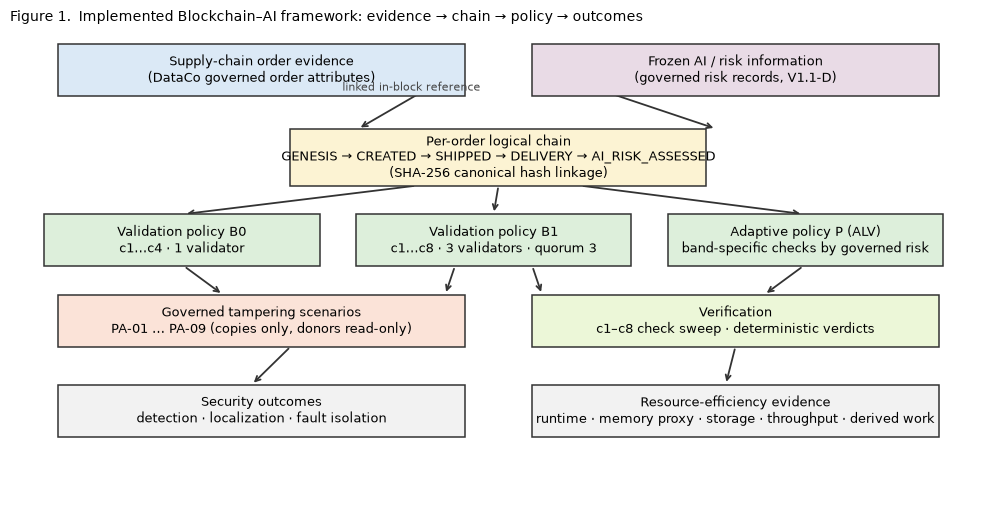

**Source artifacts:** `docs/v11_blockchain_protocol.md`, `config/blockchain_v11.yaml`, `config/experiments_v11e.yaml`, `config/ai_risk_v11d.yaml`, `src/blockchain_engine/`. The AI block carries the frozen V1.1-D `ai_risk_reference`; V1.1-E and this notebook perform no additional AI fitting or inference.

In [4]:
fig, ax = fig_start(10.0, 5.2)
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

def box(x, y, w, h, text, fc):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor="#333333", lw=1.1, zorder=2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=9, zorder=3, wrap=True)

def arrow(x0, y0, x1, y1, label=""):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="#333333", lw=1.3),
                zorder=1)
    if label:
        ax.text((x0+x1)/2, (y0+y1)/2 + 0.10, label, ha="center", va="bottom", fontsize=8, color="#444444")

c_evidence = "#dbe9f6"; c_ai = "#e9dbe6"; c_chain = "#fcf3d3"
c_policy = "#ddefdb"; c_scen = "#fbe3d8"; c_verify = "#ecf7d8"; c_out = "#f2f2f2"

box(0.5, 8.6, 4.2, 1.1, "Supply-chain order evidence\n(DataCo governed order attributes)", c_evidence)
box(5.4, 8.6, 4.2, 1.1, "Frozen AI / risk information\n(governed risk records, V1.1-D)", c_ai)

box(2.9, 6.7, 4.3, 1.2, "Per-order logical chain\nGENESIS → CREATED → SHIPPED → DELIVERY → AI_RISK_ASSESSED\n(SHA-256 canonical hash linkage)", c_chain)

box(0.35, 5.0, 2.85, 1.1, "Validation policy B0\nc1…c4 · 1 validator", c_policy)
box(3.575, 5.0, 2.85, 1.1, "Validation policy B1\nc1…c8 · 3 validators · quorum 3", c_policy)
box(6.8, 5.0, 2.85, 1.1, "Adaptive policy P (ALV)\nband-specific checks by governed risk", c_policy)

box(0.5, 3.3, 4.2, 1.1, "Governed tampering scenarios\nPA-01 … PA-09 (copies only, donors read-only)", c_scen)
box(5.4, 3.3, 4.2, 1.1, "Verification\nc1–c8 check sweep · deterministic verdicts", c_verify)

box(0.5, 1.4, 4.2, 1.1, "Security outcomes\ndetection · localization · fault isolation", c_out)
box(5.4, 1.4, 4.2, 1.1, "Resource-efficiency evidence\nruntime · memory proxy · storage · throughput · derived work", c_out)

arrow(4.7, 9.2, 3.6, 7.9, "linked in-block reference")
arrow(5.4, 9.2, 7.3, 7.9, "")
arrow(4.2, 6.7, 1.8, 6.1); arrow(5.05, 6.7, 5.0, 6.1); arrow(5.9, 6.7, 8.2, 6.1)
arrow(1.8, 5.0, 2.2, 4.4); arrow(4.6, 5.0, 4.5, 4.4)
arrow(5.4, 5.0, 5.5, 4.4); arrow(8.2, 5.0, 7.8, 4.4)
arrow(2.9, 3.3, 2.5, 2.5, "")
arrow(7.5, 3.3, 7.4, 2.5, "")

ax.set_title("Figure 1.  Implemented Blockchain–AI framework: evidence → chain → policy → outcomes",
             fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Source artifacts:** `docs/v11_blockchain_protocol.md`, `config/blockchain_v11.yaml`, "
"`config/experiments_v11e.yaml`, `config/ai_risk_v11d.yaml`, `src/blockchain_engine/`. "
"The AI block carries the frozen V1.1-D `ai_risk_reference`; V1.1-E and this notebook perform no additional AI fitting or inference."))

# 5. Blockchain Integrity and Order-Level Traceability

## 5.1 Implemented mechanisms

- **Per-order logical chain.** Each governed order owns exactly one deterministic
  chain: `ORDER_GENESIS → ORDER_CREATED → SHIPMENT_RECORDED → DELIVERY_STATUS_RECORDED
  → AI_RISK_ASSESSED` (frozen static sequence; cross-order appends are rejected).
- **Canonical serialization.** Every block is hashed as
  `SHA-256(canonical(block-without-block_hash))` where canonical = JSON with sorted
  keys, compact separators, `ensure_ascii=True` and no trailing newline.
- **Block fields (frozen schema, 11 fields).** `schema_version`, `order_id`,
  `block_index`, `event_type`, `event_timestamp`, `payload_digest`, `payload_ref`,
  `ai_risk_reference`, `validation_policy`, `previous_hash`, `block_hash`.
- **Previous-hash linkage.** Each non-genesis block stores the hash of its
  predecessor; any modification breaks the downstream chain.
- **Traceability.** Covers real governed orders (V1.1-C mapped 25,881 chains from
  34,000 rows on the train+validation metadata scope, all chains validated with
  checks c1–c8 and `ai_risk_assessed_generated=false` at C time).
- **Integrity verification.** Frozen checks `c1…c8` applied deterministically.
- **Fault isolation.** Only the affected target order's chain diverges; the donors
  of `PA-08/PA-09` are read-only, and no cross-order propagation is observed.

,Check,Meaning
0,c1,schema conformance
1,c2,self block_hash recomputation
2,c3,previous_hash linkage
3,c4,event timestamp non-decreasing per order
4,c5,order_integrity (canonical order_id chain pref...
5,c6,ai_risk_reference present for AI-linked event ...
6,c7,ai_risk_reference digest re-verification
7,c8,chain prefix re-verification (prior blocks has...


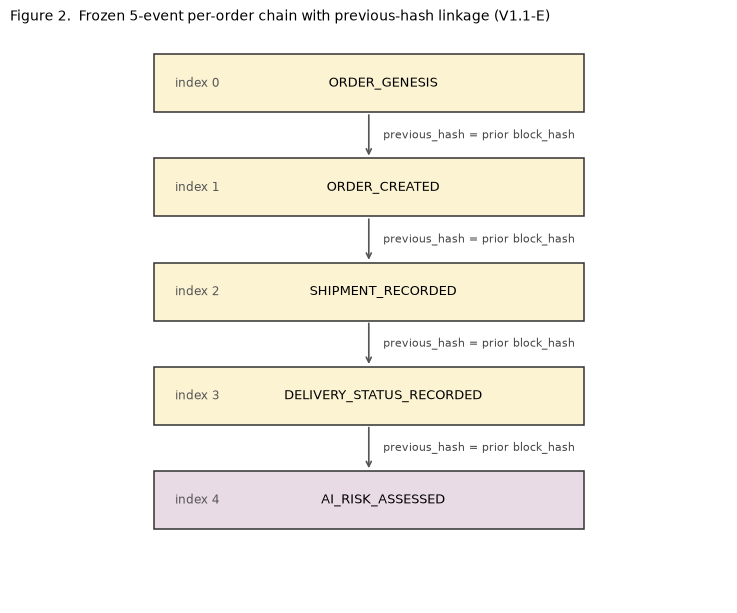

**Mapping evidence (V1.1-C):** `chains_constructed = 25881`, `chains_validated = 25881`, `total_rows_mapped = 34000`, `orders_failed = 0`, `ai_risk_assessed_generated = false`, `chain_length = 4` at C time. Source: `results/blockchain/v11c/v11c_mapping_summary.json`.

In [5]:
# ---- block schema + check meanings from frozen config ----
import yaml
v11cfg = yaml.safe_load((REPO / "config" / "blockchain_v11.yaml").read_text(encoding="utf-8"))

checks = v11cfg["validation"]["core_checks"]
check_df = pd.DataFrame([{"Check": k, "Meaning": v} for k, v in checks.items() if k.startswith("c")])
display(check_df)

# ---- deterministic vertical chain schematic (no random data) ----
fig, ax = fig_start(7.8, 6.6)
ax.set_xlim(0, 10); ax.set_ylim(0, 12.4); ax.axis("off")
events = ["ORDER_GENESIS", "ORDER_CREATED", "SHIPMENT_RECORDED",
          "DELIVERY_STATUS_RECORDED", "AI_RISK_ASSESSED"]
ys = np.linspace(10.6, 1.6, len(events))
for i, (ev, y) in enumerate(zip(events, ys)):
    fc = "#fcf3d3" if ev != "AI_RISK_ASSESSED" else "#e9dbe6"
    ax.add_patch(plt.Rectangle((2.0, y), 6.0, 1.25, facecolor=fc, edgecolor="#333333", lw=1.1, zorder=2))
    ax.text(2.3, y + 0.625, f"index {i}", ha="left", va="center", fontsize=8.5, color="#555555", zorder=3)
    ax.text(5.2, y + 0.625, ev, ha="center", va="center", fontsize=9.5, zorder=3)
    if i > 0:
        ax.annotate("", xy=(5.0, y + 1.25), xytext=(5.0, ys[i - 1]),
                    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.2))
        ax.text(5.2, (ys[i - 1] + y + 1.25) / 2,
                "previous_hash = prior block_hash", ha="left", va="center", fontsize=8, color="#444444")
ax.set_title("Figure 2.  Frozen 5-event per-order chain with previous-hash linkage (V1.1-E)",
             fontsize=10, loc="left")
fig.subplots_adjust(left=0.04, right=0.96, top=0.90, bottom=0.03); plt.show()

display(Markdown(
f"**Mapping evidence (V1.1-C):** `chains_constructed = 25881`, `chains_validated = 25881`, "
f"`total_rows_mapped = 34000`, `orders_failed = 0`, `ai_risk_assessed_generated = false`, "
f"`chain_length = 4` at C time. Source: `results/blockchain/v11c/v11c_mapping_summary.json`."))

# 6. AI/Risk Integration

## 6.1 Governance

V1.1-D performed the authorized deterministic model reconstruction/fitting on frozen TRAIN
workloads and five-seed `predict_proba(class=1)` scoring on clean frozen VALIDATION inputs.
Those governed risk records were frozen before the blockchain experiment. V1.1-E consumed
them as `GOVERNED_AI_RISK` without additional AI fitting or inference; V1.1-F and this
notebook likewise perform no AI fitting or inference. TEST remained unopened. Risk modes and
thresholds were pre-registered and frozen, never tuned with evaluation outcomes.

## 6.2 Governed population

The frozen population comprises **4,588 governed orders** with the following risk
band distribution:

| Band | Count | Note |
|---|---|---|
| LOW | 0 | `LOW_ABSENT_IN_GOVERNED_POPULATION` |
| MEDIUM | 4,582 | dominant band |
| HIGH | 6 | sparse, descriptive-only |

**Explicit limitations:** LOW is **absent** from the governed population; HIGH is
**sparse** (6/4,588) and **not observed** at workload 100
(`HIGH_NOT_OBSERVED_IN_CONDITION`). Subgroup behaviour is therefore **not**
generalized; all policy-level evidence is described as overwhelmingly MEDIUM-driven.

,Band,Count (governed population),Workload-100 presence,Evidence stance
0,LOW,0,absent,none (marker)
1,MEDIUM,4582,present,principal
2,HIGH,6,absent,sparse descriptive


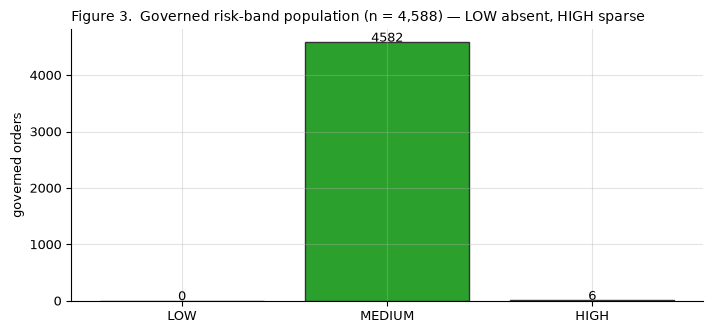

**Sources:** `results/blockchain/v11d/v11d_generation_summary.json` (risk_distribution), `results/blockchain/v11f/v11f_analysis_results.json` (population_limitations). Flags `LOW_ABSENT_IN_GOVERNED_POPULATION` and `HIGH_NOT_OBSERVED_IN_CONDITION` are persisted markers.

In [6]:
gen = load_json("results/blockchain/v11d/v11d_generation_summary.json").get("result", None)
if gen is None:
    # nested under 'result' may be absent; handle flat layout
    gen = load_json("results/blockchain/v11d/v11d_generation_summary.json")

risk_dist = gen.get("risk_distribution", pop.get("risk_band_counts", {}))
bands = ["LOW", "MEDIUM", "HIGH"]
risk_tab = pd.DataFrame({
    "Band": bands,
    "Count (governed population)": [risk_dist.get("LOW", 0), risk_dist.get("MEDIUM", 4582), risk_dist.get("HIGH", 6)],
    "Workload-100 presence": ["absent", "present", "absent"],
    "Evidence stance": ["none (marker)", "principal", "sparse descriptive"],
})
display(risk_tab)

fig, ax = fig_start(7.2, 3.4)
vals = [risk_dist.get("LOW", 0), risk_dist.get("MEDIUM", 4582), risk_dist.get("HIGH", 6)]
bars = ax.bar(bands, vals, color=["#9e9e9e", "#2ca02c", "#d24726"], edgecolor="#333333")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 10, str(v), ha="center", fontsize=9)
ax.set_ylabel("governed orders")
ax.set_title("Figure 3.  Governed risk-band population (n = 4,588) — LOW absent, HIGH sparse",
             fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Sources:** `results/blockchain/v11d/v11d_generation_summary.json` (risk_distribution), "
"`results/blockchain/v11f/v11f_analysis_results.json` (population_limitations). "
"Flags `LOW_ABSENT_IN_GOVERNED_POPULATION` and `HIGH_NOT_OBSERVED_IN_CONDITION` are persisted markers."))

# 7. Validation Policies: B0, B1, P

Policies are built directly from the frozen experiment configuration
(`config/experiments_v11e.yaml`), quoted exactly. All policies evaluate the
identical workload, serialization, hash scheme, attack instances, machine, seeds and
procedure; only the validation policy differs (`B1_minus_B0`/`P_minus_B0` matched
persisted comparisons).

- **B0** — fixed baseline: a single authorized validator applying checks `c1…c4`
  to every block.
- **B1** — fixed stronger validation: a quorum of **3** deterministic authorized
  validators applying `c1…c8` to every block.
- **P (ALV)** — adaptive: band-specific check sets and validator counts driven by
  the governed risk record (`GOVERNED_AI_RISK`).

In [7]:
exp_cfg = yaml.safe_load((REPO / "config" / "experiments_v11e.yaml").read_text(encoding="utf-8"))
policies = exp_cfg["policies"]

rows = []
rows.append({"Policy": "B0", "Mode": "fixed baseline", "Risk input": "none",
             "Band/checks": "c1, c2, c3, c4", "Validators": 1, "Notes": "single authorized validator"})
rows.append({"Policy": "B1", "Mode": "fixed stronger", "Risk input": "none",
             "Band/checks": "c1 … c8", "Validators": 3, "Notes": "quorum 3 (deterministic)"})
p = policies["P"]
pd_rows = []
for band, spec in p["bands"].items():
    pd_rows.append({
        "Policy": "P",
        "Mode": p["mode"],
        "Risk input": p["risk_input"],
        "Band/checks": band + " -> " + ", ".join(spec["checks"]),
        "Validators": spec["validators"],
        "Notes": "adaptive; band from governed risk",
    })
rows += pd_rows
policy_df = pd.DataFrame(rows)
display(policy_df)

display(Markdown(
"**Source:** `config/experiments_v11e.yaml` (`policies`). The P risk-to-checks mapping "
"reproduces `config/blockchain_v11.yaml` `adaptive_lightweight_validation.band_to_checks`. "
"No policy is labelled best/winner/optimal/superior/recommended."))

,Policy,Mode,Risk input,Band/checks,Validators,Notes
0,B0,fixed baseline,none,"c1, c2, c3, c4",1,single authorized validator
1,B1,fixed stronger,none,c1 … c8,3,quorum 3 (deterministic)
2,P,AI_DRIVEN_ADAPTIVE_ALV,GOVERNED_AI_RISK,"LOW -> c1, c2, c3, c4",1,adaptive; band from governed risk
3,P,AI_DRIVEN_ADAPTIVE_ALV,GOVERNED_AI_RISK,"MEDIUM -> c1, c2, c3, c4, c5, c6",1,adaptive; band from governed risk
4,P,AI_DRIVEN_ADAPTIVE_ALV,GOVERNED_AI_RISK,"HIGH -> c1, c2, c3, c4, c5, c6, c7, c8",3,adaptive; band from governed risk


**Source:** `config/experiments_v11e.yaml` (`policies`). The P risk-to-checks mapping reproduces `config/blockchain_v11.yaml` `adaptive_lightweight_validation.band_to_checks`. No policy is labelled best/winner/optimal/superior/recommended.

# 8. Governed Cyber/Tampering Scenarios PA-01 … PA-09

The threat model (frozen in V1.1-A, section 14) considers an **off-chain actor**
(malicious or accidental) reaching local archives and tampering with *copies*; no
full-node compromise or adversarial supermajority is assumed. All attacks run on
generated experiment copies only, never on frozen production artifacts.

**Instance contract (verified from the V1.1-E4 manifest):** every attack condition
tampers one **target order chain**; `PA-08`/`PA-09` borrow a **read-only donor**
(`donor_read_only = true`) and only target blocks are copied (`copy_only_target_blocks = true`).

In [8]:
att_manifest = load_json("results/blockchain/v11e/v11e_attack_instance_manifest.json")
r = att_manifest.get("result", att_manifest)

# authoritative tamper kinds discovered from persisted instances
kinds = {}
for seed in r["by_seed"].values():
    for wl in seed.values():
        for pa, inst in wl.items():
            kinds[inst["scenario_id"]] = inst["tamper_kind"]

scenarios = [
    ("PA-01", "payload modification"),
    ("PA-02", "block deletion"),
    ("PA-03", "block insertion"),
    ("PA-04", "previous-hash modification"),
    ("PA-05", "order-id modification"),
    ("PA-06", "AI-risk record modification"),
    ("PA-07", "chain truncation"),
    ("PA-08", "cross-order substitution"),
    ("PA-09", "cross-order replay"),
]
mechanisms = {
    "PA-01": "payload_digest mismatch at the affected block",
    "PA-02": "previous_hash mismatch / index gap",
    "PA-03": "previous_hash mismatch / index gap",
    "PA-04": "block_hash recomputation mismatch",
    "PA-05": "genesis order_id prefix mismatch vs expected chain id",
    "PA-06": "ai_risk_reference digest verification failure",
    "PA-07": "declared block_count vs chained reach",
    "PA-08": "per-order chain identity checks (summary layer)",
    "PA-09": "timestamp / order coherence + per-order uniqueness checks",
}
pa_rows = []
for pa, desc in scenarios:
    pa_rows.append({
        "Attack": pa,
        "Description": desc,
        "Affected mechanism": mechanisms[pa],
        "B0": "E02 evidence",
        "B1": "E02 evidence",
        "P": "E02 evidence",
        "Frozen name": kinds.get(pa, ""),
    })
pa_df = pd.DataFrame(pa_rows)
display(pa_df)

display(Markdown(
f"**Verified from persisted artifacts:** tamper kinds match the above for all 9 scenarios "
f"(e.g. `PA-01 = {kinds.get('PA-01')}`, `PA-06 = {kinds.get('PA-06')}`). Instance manifest: "
f"`donor_read_only = {r['donor_read_only']}`, `copy_only_target_blocks = {r['copy_only_target_blocks']}`, "
f"sizes = {r['sizes']}, seeds = {r['seeds']}, stage = {r['stage']}. "
f"Per-policy detection values are presented in Section 10 (E02)."))

,Attack,Description,Affected mechanism,B0,B1,P,Frozen name
0,PA-01,payload modification,payload_digest mismatch at the affected block,E02 evidence,E02 evidence,E02 evidence,PAYLOAD_MODIFICATION
1,PA-02,block deletion,previous_hash mismatch / index gap,E02 evidence,E02 evidence,E02 evidence,BLOCK_DELETION
2,PA-03,block insertion,previous_hash mismatch / index gap,E02 evidence,E02 evidence,E02 evidence,BLOCK_INSERTION
3,PA-04,previous-hash modification,block_hash recomputation mismatch,E02 evidence,E02 evidence,E02 evidence,PREVIOUS_HASH_MODIFICATION
4,PA-05,order-id modification,genesis order_id prefix mismatch vs expected c...,E02 evidence,E02 evidence,E02 evidence,ORDER_ID_MODIFICATION
5,PA-06,AI-risk record modification,ai_risk_reference digest verification failure,E02 evidence,E02 evidence,E02 evidence,AI_RISK_RECORD_MODIFICATION
6,PA-07,chain truncation,declared block_count vs chained reach,E02 evidence,E02 evidence,E02 evidence,CHAIN_TRUNCATION
7,PA-08,cross-order substitution,per-order chain identity checks (summary layer),E02 evidence,E02 evidence,E02 evidence,CROSS_ORDER_SUBSTITUTION
8,PA-09,cross-order replay,timestamp / order coherence + per-order unique...,E02 evidence,E02 evidence,E02 evidence,CROSS_ORDER_REPLAY


**Verified from persisted artifacts:** tamper kinds match the above for all 9 scenarios (e.g. `PA-01 = PAYLOAD_MODIFICATION`, `PA-06 = AI_RISK_RECORD_MODIFICATION`). Instance manifest: `donor_read_only = True`, `copy_only_target_blocks = True`, sizes = [100, 250, 500, 1000, 2500], seeds = [522, 523, 524], stage = V1.1-E4L. Per-policy detection values are presented in Section 10 (E02).

# 9. E01–E10 Experimental Map

The governed campaign comprises **390 cells = 345 measured + 45 E10 derived**,
running under seeds 522–524 and nested workloads 100/250/500/1000/2500. Counts below
are the verified persisted per-experiment cell tallies.

In [9]:
e_map = [
    ("E01", 45, "B0/B1/P", "Functional correctness", "functional", "measured"),
    ("E02", 45, "B0/B1/P", "Integrity/tamper detection", "security", "measured"),
    ("E03", 45, "B0/B1/P", "Tamper localization", "security (mirrors E02)", "measured"),
    ("E04", 45, "B0/B1/P", "Order-level fault isolation", "security", "measured"),
    ("E05", 15, "P only", "AI-linked adaptive behaviour", "security/adaptive", "measured"),
    ("E06", 45, "B0/B1/P", "Execution-time overhead", "runtime", "measured"),
    ("E07", 45, "B0/B1/P", "Memory overhead", "memory proxy", "measured"),
    ("E08", 15, "POLICY_INDEPENDENT", "Storage overhead", "storage", "measured (policy-independent)"),
    ("E09", 45, "B0/B1/P", "Throughput", "throughput", "measured"),
    ("E10", 45, "B0/B1/P", "Derived computational-work / green proxy", "computational work", "DERIVED_ONLY"),
]
e_map_df = pd.DataFrame(e_map, columns=["Experiment", "Cells", "Policies", "Purpose", "Metric family", "Evidence type"])
display(e_map_df)

display(Markdown(
"**E10 is `DERIVED_ONLY`**: it carries no independent measurement campaign and is recomputed from "
"re-verified persisted E06–E09 cell evidence (see Section 18). E08 is `POLICY_INDEPENDENT`; its stored "
"B0 token is a serialization placeholder, not a policy comparison."))

,Experiment,Cells,Policies,Purpose,Metric family,Evidence type
0,E01,45,B0/B1/P,Functional correctness,functional,measured
1,E02,45,B0/B1/P,Integrity/tamper detection,security,measured
2,E03,45,B0/B1/P,Tamper localization,security (mirrors E02),measured
3,E04,45,B0/B1/P,Order-level fault isolation,security,measured
4,E05,15,P only,AI-linked adaptive behaviour,security/adaptive,measured
5,E06,45,B0/B1/P,Execution-time overhead,runtime,measured
6,E07,45,B0/B1/P,Memory overhead,memory proxy,measured
7,E08,15,POLICY_INDEPENDENT,Storage overhead,storage,measured (policy-independent)
8,E09,45,B0/B1/P,Throughput,throughput,measured
9,E10,45,B0/B1/P,Derived computational-work / green proxy,computational work,DERIVED_ONLY


**E10 is `DERIVED_ONLY`**: it carries no independent measurement campaign and is recomputed from re-verified persisted E06–E09 cell evidence (see Section 18). E08 is `POLICY_INDEPENDENT`; its stored B0 token is a serialization placeholder, not a policy comparison.

# 10. Attack Detection — E02

## 10.1 Detection summary (governed run)

`E02` measures the **policy-specific** verdict: *that policy rejects the attacked
chain* (not a generic attack harness). Expected persisted counts:
`B0 = 30 / 135`, `B1 = 105 / 135`, `P = 75 / 135`.

,Policy,Detected,Denominator,Detection rate
0,B0,30,135,0.2222
1,B1,105,135,0.7778
2,P,75,135,0.5556


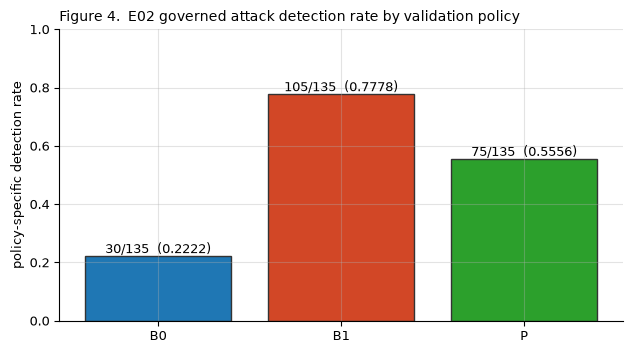

**Source:** `results/blockchain/v11f/v11f_analysis_results.json` (security_context.e02_detection_counts) and `results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E02.json`. Descriptive only; no significance or ranking is implied.

In [10]:
det = {"B0": 30, "B1": 105, "P": 75}
den = 135
det_df = pd.DataFrame({
    "Policy": POLICIES,
    "Detected": [det[p] for p in POLICIES],
    "Denominator": [den]*3,
    "Detection rate": [round(det[p]/den, 4) for p in POLICIES],
})
display(det_df)

fig, ax = fig_start(6.4, 3.6)
bars = ax.bar(POLICIES, [det[p]/den for p in POLICIES],
              color=[POLICY_COLORS[p] for p in POLICIES], edgecolor="#333333")
for b, p in zip(bars, POLICIES):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f"{det[p]}/135  ({det[p]/den:.4f})", ha="center", fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel("policy-specific detection rate")
ax.set_title("Figure 4.  E02 governed attack detection rate by validation policy", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Source:** `results/blockchain/v11f/v11f_analysis_results.json` (security_context.e02_detection_counts) "
"and `results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E02.json`. Descriptive only; no "
"significance or ranking is implied."))

## 10.2 PA-01 … PA-09 × policy detection matrix

The governed summary aggregates only per-policy totals; the per-scenario pattern is
reconstructed here from the 45 persisted `E02` cells (`E02_s{seed}_w{size}_p{policy}.json`,
each holding one `detection_outcome` per PA condition). This is descriptive
bookkeeping of already-frozen evidence, not a new experiment.

,PA,B0,B1,P
0,PA-01,0/15,0/15,0/15
1,PA-02,15/15,15/15,15/15
2,PA-03,15/15,15/15,15/15
3,PA-04,0/15,15/15,0/15
4,PA-05,0/15,15/15,15/15
5,PA-06,0/15,15/15,0/15
6,PA-07,0/15,0/15,0/15
7,PA-08,0/15,15/15,15/15
8,PA-09,0/15,15/15,15/15


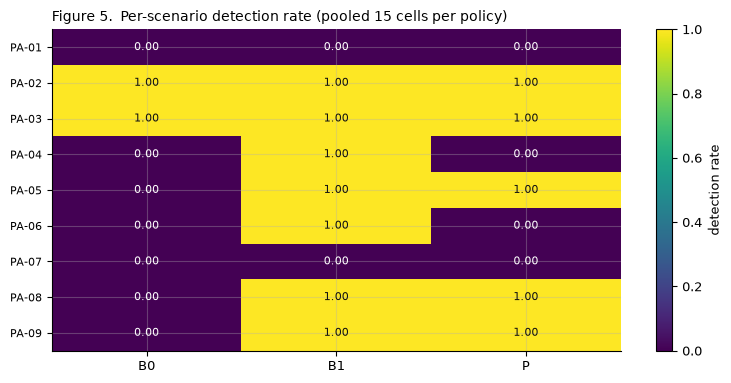

Rows are the 9 governed scenarios; values are detection rates pooled over the 15 seed×workload cells per policy. Scenario-level outcomes are conditional on the governed MEDIUM-majority population and the frozen threat model; they are not a ranking of scenario difficulty nor a claim about other populations. Workload prefixes are nested within each seed and are not independent replicates.

In [11]:
e02_dir = REPO / "results" / "blockchain" / "v11e" / "v11e_experiment_results" / "V1.1-E4"
pa_detect = {p: {} for p in POLICIES}
pa_seen = {p: {} for p in POLICIES}
for seed in (522, 523, 524):
    for wl in (100, 250, 500, 1000, 2500):
        for pol in POLICIES:
            fname = f"E02_s{seed}_w{wl:05d}_p{pol}.json"
            cell = json.loads((e02_dir / fname).read_text(encoding="utf-8"))
            for rec in cell["result"]["raw_records"]:
                pa = rec["attack"]
                pa_detect[pol][pa] = pa_detect[pol].get(pa, 0) + (1 if rec["detection_outcome"] else 0)
                pa_seen[pol][pa] = pa_seen[pol].get(pa, 0) + 1

mat_rows = []
for pa in sorted({pa for p in POLICIES for pa in pa_detect[p]}):
    mat_rows.append({"PA": pa,
                     "B0": f"{pa_detect['B0'][pa]}/{pa_seen['B0'][pa]}",
                     "B1": f"{pa_detect['B1'][pa]}/{pa_seen['B1'][pa]}",
                     "P":  f"{pa_detect['P'][pa]}/{pa_seen['P'][pa]}"})
mat_df = pd.DataFrame(mat_rows)
display(mat_df)

fig, ax = fig_start(7.8, 3.9)
mat = np.array([[pa_detect[p][pa]/pa_seen[p][pa] for p in POLICIES]
                for pa in sorted(pa_detect["B0"])])
im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(POLICIES)
ax.set_yticks(range(len(mat))); ax.set_yticklabels(sorted(pa_detect["B0"]), fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if mat[i,j] < 0.5 else "#111111")
ax.set_title("Figure 5.  Per-scenario detection rate (pooled 15 cells per policy)", fontsize=10, loc="left")
plt.colorbar(im, ax=ax, label="detection rate")
plt.tight_layout(); plt.show()

display(Markdown(
"Rows are the 9 governed scenarios; values are detection rates pooled over the 15 "
"seed×workload cells per policy. Scenario-level outcomes are conditional on the "
"governed MEDIUM-majority population and the frozen threat model; they are not a "
"ranking of scenario difficulty nor a claim about other populations. Workload prefixes are "
"nested within each seed and are not independent replicates."))

# 11. Localization Context — E03

> **Important caveat:** **E03 is NOT independent confirmatory evidence.**
> In the governed V1.1-E campaign the binary localization outcome **mirrored E02
> detection** (`e03_independent_confirmatory_evidence = false`). Per the frozen
> E03 protocol, the localization denominator is *all attacks* (an undetected attach
> is counted as not localized), so localization rates equal detection rates by
> construction. No second, potentially misleading, independent visualization is
> created here.

In [12]:
loc_body = load_json("results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E03.json")
ll = loc_body["per_policy"]
loc_rows = []
for p in POLICIES:
    r = ll[p]["rates"]["localization_outcome.localized"]
    loc_rows.append({"Policy": p, "Localized": r["numerator"], "Denominator": r["denominator"],
                     "Rate": round(r["rate"], 4)})
loc_df = pd.DataFrame(loc_rows)
display(loc_df)

display(Markdown(
"**Why E03 is not independent:** synthetic tampering is disclosed as laboratory "
"scenarios on generated copies; an undetected tamper is not localized "
"(`NOT_LOCALIZED_UNDETECTED_ATTACK`), so the binary localization record is deterministically "
"tied to the E02 detection verdict. The frozen analysis explicitly records "
"`e03_independent_confirmatory_evidence = false`."))

,Policy,Localized,Denominator,Rate
0,B0,30,135,0.2222
1,B1,105,135,0.7778
2,P,75,135,0.5556


**Why E03 is not independent:** synthetic tampering is disclosed as laboratory scenarios on generated copies; an undetected tamper is not localized (`NOT_LOCALIZED_UNDETECTED_ATTACK`), so the binary localization record is deterministically tied to the E02 detection verdict. The frozen analysis explicitly records `e03_independent_confirmatory_evidence = false`.

# 12. Fault Isolation — E04

`E04` checks that **only the affected target chain** is affected: all
**unaffected orders are preserved**. Each attack condition has exactly one affected
target chain; `PA-08/PA-09` keep the donor read-only and the target is the affected
chain. Persisted result: **117,315 / 117,315 unaffected orders preserved per policy**.

In [13]:
pres = load_json("results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E04.json")
pp = pres["per_policy"]
pres_rows = []
for p in POLICIES:
    r = pp[p]["rates"]["localization_outcome.preservation"]
    pres_rows.append({"Policy": p, "Unaffected preserved": r["numerator"],
                      "Denominator": r["denominator"], "Rate": round(r["rate"], 6)})
pres_df = pd.DataFrame(pres_rows)
display(pres_df)

display(Markdown(
"`cross_order_propagation_count = 0` in the persisted E04 cells, consistent with "
"donor read-only semantics. Files: `E04_s{seed}_w{size}_p{policy}.json` and aggregate "
"`E04.json`. Isolation is demonstrated **for the governed attack set** only; it is not "
"a guarantee about ungoverned scenarios."))

,Policy,Unaffected preserved,Denominator,Rate
0,B0,117315,117315,1.0
1,B1,117315,117315,1.0
2,P,117315,117315,1.0


`cross_order_propagation_count = 0` in the persisted E04 cells, consistent with donor read-only semantics. Files: `E04_s{seed}_w{size}_p{policy}.json` and aggregate `E04.json`. Isolation is demonstrated **for the governed attack set** only; it is not a guarantee about ungoverned scenarios.

# 13. Adaptive Policy Behaviour — E05

`E05` measures **policy P's** risk-driven allocation of validation checks and
validators (15 P-only cells). The principal evidence uses the **governed AI risk**
level. For the governed population this is overwhelmingly MEDIUM; `LOW` is absent;
`HIGH` appears only at workloads ≥ 250 and never at workload 100.

,seed,workload,risk band,orders,validation checks,validator count
0,522,100,MEDIUM,100,600,100
9,523,100,MEDIUM,100,600,100
18,524,100,MEDIUM,100,600,100
1,522,250,HIGH,1,8,3
10,523,250,HIGH,1,8,3
19,524,250,HIGH,1,8,3
2,522,250,MEDIUM,249,1494,249
11,523,250,MEDIUM,249,1494,249
20,524,250,MEDIUM,249,1494,249
3,522,500,HIGH,2,16,6


… 27 risk-band-level rows derived from 15 P experiment cells. Aggregated by workload:

,workload,risk band,orders,validation checks,validator count
0,100,MEDIUM,300,1800,300
1,250,HIGH,3,24,9
2,250,MEDIUM,747,4482,747
3,500,HIGH,5,40,15
4,500,MEDIUM,1495,8970,1495
5,1000,HIGH,7,56,21
6,1000,MEDIUM,2993,17958,2993
7,2500,HIGH,14,112,42
8,2500,MEDIUM,7486,44916,7486


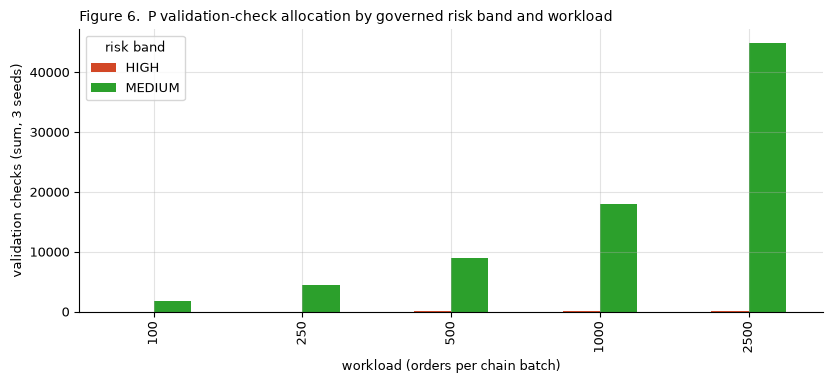

**Reading:** at workload 100 there are **no HIGH orders** (`HIGH_NOT_OBSERVED_IN_CONDITION`); when HIGH orders appear (workloads ≥ 250), P applies 8 checks on 3 validators to them while MEDIUM orders receive 6 checks on 1 validator. Source: 15 persisted `E05_s*_pP.json` cells. Workload prefixes are nested within each seed and are not independent replicates.

In [14]:
e05_dir = REPO / "results" / "blockchain" / "v11e" / "v11e_experiment_results" / "V1.1-E4"
e05_rows = []
for seed in (522, 523, 524):
    for wl in (100, 250, 500, 1000, 2500):
        fname = f"E05_s{seed}_w{wl:05d}_pP.json"
        cell = json.loads((e05_dir / fname).read_text(encoding="utf-8"))["result"]["primary"]
        dist = cell["validation_level_distribution"]
        alloc = cell["applied_validation_check_allocation_by_governed_risk"]
        for band, cnt in sorted(dist.items()):
            n_orders = cnt
            checks = alloc[band]["validation_checks"]
            vals = alloc[band]["validator_count"]
            e05_rows.append({"seed": seed, "workload": wl, "risk band": band,
                             "orders": n_orders, "validation checks": checks,
                             "validator count": vals})
e05_df = pd.DataFrame(e05_rows)
display(e05_df.sort_values(["workload", "risk band"]).head(12))
display(Markdown(f"… {len(e05_df)} risk-band-level rows derived from 15 P experiment cells. Aggregated by workload:"))
summ = e05_df.groupby(["workload", "risk band"])[["orders", "validation checks", "validator count"]].sum().reset_index()
display(summ)

fig, ax = fig_start(8.4, 3.9)
import pandas as pd
piv = summ.pivot(index="workload", columns="risk band", values="validation checks").reindex([100,250,500,1000,2500]).fillna(0)
ax = piv.plot(kind="bar", ax=ax, color={"MEDIUM": "#2ca02c", "HIGH": "#d24726", "LOW": "#9e9e9e"})
ax.set_ylabel("validation checks (sum, 3 seeds)")
ax.set_xlabel("workload (orders per chain batch)")
ax.set_title("Figure 6.  P validation-check allocation by governed risk band and workload", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Reading:** at workload 100 there are **no HIGH orders** (`HIGH_NOT_OBSERVED_IN_CONDITION`); "
"when HIGH orders appear (workloads ≥ 250), P applies 8 checks on 3 validators to them while "
"MEDIUM orders receive 6 checks on 1 validator. Source: 15 persisted `E05_s*_pP.json` cells. "
"Workload prefixes are nested within each seed and are not independent replicates."))

# 14. Runtime and CPU Evidence — E06

`E06` is the **principal timing experiment** (`timing_role = PRINCIPAL`), measuring
validation-only runs. Units are persisted nanosecond labels
(`cpu_time_ns` / `wall_time_ns`, per-order persisted runs) — verified in the cells
as exact labels. **These are runtime evidence, not energy.**

,Policy,CPU mean (ns),CPU median (ns),Wall mean (ns),Wall median (ns),n cells
0,B0,53189.386,52082.356,51063.607,49743.996,15
1,B1,331166.419,326487.428,318159.839,315966.191,15
2,P,74081.177,72514.938,71100.787,69758.644,15


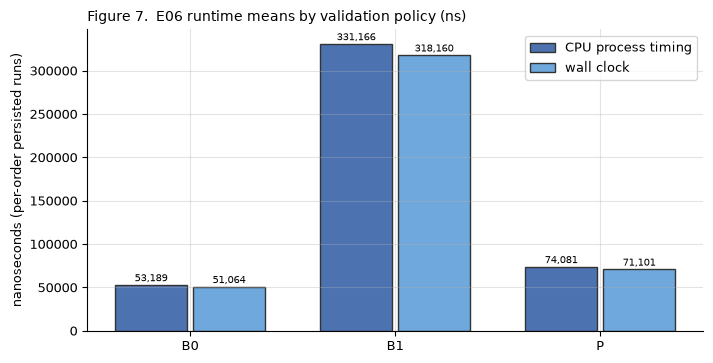

**Units:** `cpu_time_ns` / `wall_time_ns` (nanoseconds, per-order persisted runs) as embedded in the frozen V1.1-E metric labels. Values are descriptive means over the 15 governed cells per policy. Runtime is a computational resource proxy; it is **not** energy.

In [15]:
e06 = load_json("results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E06.json")["per_policy"]
rt_rows = []
for p in POLICIES:
    cpu = e06[p]["metrics"]["cpu_time_ns"]
    wall = e06[p]["metrics"]["wall_time_ns"]
    rt_rows.append({
        "Policy": p,
        "CPU mean (ns)": round(cpu["mean"], 3), "CPU median (ns)": round(cpu["median"], 3),
        "Wall mean (ns)": round(wall["mean"], 3), "Wall median (ns)": round(wall["median"], 3),
        "n cells": 15,
    })
rt_df = pd.DataFrame(rt_rows)
display(rt_df)

fig, ax = fig_start(7.2, 3.7)
x = np.arange(3); w = 0.38
cpu = [rt_df.loc[i, "CPU mean (ns)"] for i in range(3)]
wall = [rt_df.loc[i, "Wall mean (ns)"] for i in range(3)]
b1 = ax.bar(x - w/2, cpu, w*0.92, label="CPU process timing", color="#4c72b0", edgecolor="#333333")
b2 = ax.bar(x + w/2, wall, w*0.92, label="wall clock", color="#6fa8dc", edgecolor="#333333")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 4000,
                f"{b.get_height():,.0f}", ha="center", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(POLICIES)
ax.set_ylabel("nanoseconds (per-order persisted runs)")
ax.legend()
ax.set_title("Figure 7.  E06 runtime means by validation policy (ns)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Units:** `cpu_time_ns` / `wall_time_ns` (nanoseconds, per-order persisted runs) as embedded "
"in the frozen V1.1-E metric labels. Values are descriptive means over the 15 governed cells "
"per policy. Runtime is a computational resource proxy; it is **not** energy."))

## 14.1 Workload-level runtime pattern

Runtime versus nested workload (per-policy means over the 3 seeds) uses the frozen
F2 per-workload descriptive summaries.

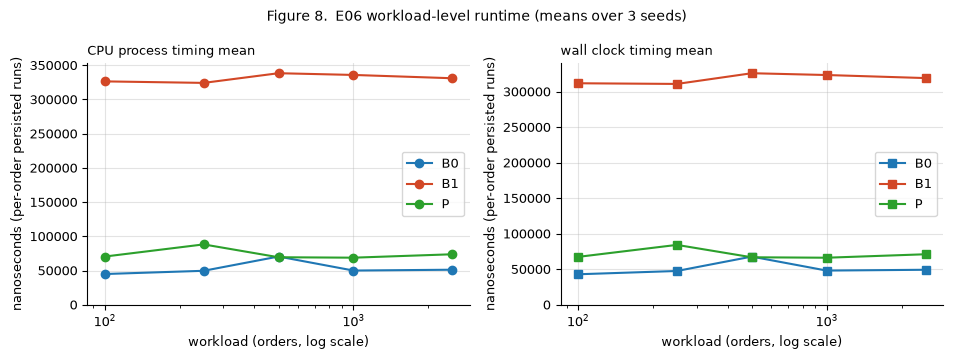

Workloads are **nested** within each seed and are **not** independent replicates; lines are descriptive and shown in deterministic policy order B0, B1, P.

In [16]:
f2_ds = f2["descriptive_summaries"]["per_workload_per_policy"]
wl_list = [100, 250, 500, 1000, 2500]

fig, ([ax1, ax2]) = plt.subplots(1, 2, figsize=(9.6, 3.6))
for p in POLICIES:
    cpu_vals = [f2_ds["persisted_cpu_process_timing"][str(wl)][p]["mean"] for wl in wl_list]
    wall_vals = [f2_ds["persisted_wall_clock_timing"][str(wl)][p]["mean"] for wl in wl_list]
    ax1.plot(wl_list, cpu_vals, marker="o", label=p, color=POLICY_COLORS[p])
    ax2.plot(wl_list, wall_vals, marker="s", label=p, color=POLICY_COLORS[p])
for a, t in [(ax1, "CPU process timing mean"), (ax2, "wall clock timing mean")]:
    a.set_xscale("log"); a.set_xlabel("workload (orders, log scale)")
    a.set_ylabel("nanoseconds (per-order persisted runs)")
    a.set_ylim(0, None)
    a.set_title(t, fontsize=9, loc="left")
ax1.legend(); ax2.legend()
plt.suptitle("Figure 8.  E06 workload-level runtime (means over 3 seeds)", fontsize=10)
plt.tight_layout(); plt.show()

display(Markdown(
"Workloads are **nested** within each seed and are **not** independent replicates; "
"lines are descriptive and shown in deterministic policy order B0, B1, P."))

# 15. Computational Memory Proxy — E07

## 15.1 Labelling

The frozen label is **`COMPUTATIONAL_MEMORY_PROXY`**. The measured quantity is the
**fresh-process Python `tracemalloc` peak** during validation (persisted unit
`memory_proxy_mib`, measurement `tracemalloc_fresh_worker`).

It is **NOT**: resident set size (RSS), physical memory, system memory, or electrical
energy.

,Policy,mean (MiB),median (MiB),min (MiB),max (MiB),n cells
0,B0,1.265201,1.265202,1.265200,1.265202,15
1,B1,1.265740,1.265740,1.265738,1.265742,15
2,P,1.265695,1.265695,1.265694,1.265696,15


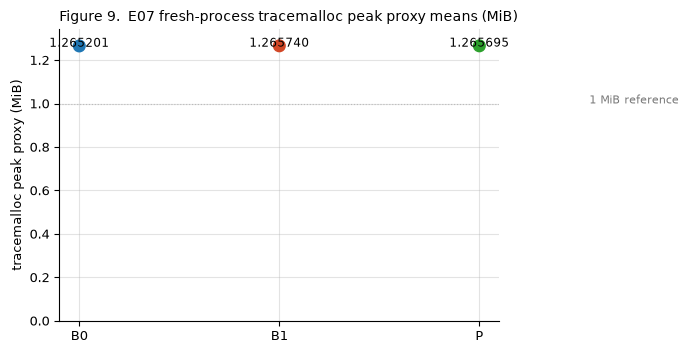

All three policies show a mean proxy of ≈ **1.265 MiB**; differences between policies are **< 0.001 MiB** (about 0.0005 MiB), i.e. a Python traced-allocation spread, not a meaningful memory-consumption separation. **Not energy.**

In [17]:
e07 = load_json("results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E07.json")["per_policy"]
mem_rows = []
for p in POLICIES:
    m = e07[p]["metrics"]["memory_proxy_mib"]
    mem_rows.append({
        "Policy": p,
        "mean (MiB)": round(m["mean"], 6), "median (MiB)": round(m["median"], 6),
        "min (MiB)": round(m["min"], 6), "max (MiB)": round(m["max"], 6),
        "n cells": 15,
    })
mem_df = pd.DataFrame(mem_rows)
display(mem_df)

# policy-specific plot with an honest, fully labelled y-axis
fig, ax = fig_start(7.2, 3.6)
xs = np.arange(3)
means = [mem_df.loc[i, "mean (MiB)"] for i in range(3)]
ax.scatter(xs, means, s=70, color=[POLICY_COLORS[p] for p in POLICIES], zorder=3)
ax.axhline(1.0, color="#bbbbbb", lw=0.8, ls=":")
ax.text(2.55, 1.0005, "1 MiB reference", fontsize=8, color="#777777")
for i, m in enumerate(means):
    ax.annotate(f"{m:.6f}", (i, m), xytext=(i, m - 0.004), ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(POLICIES)
ax.set_ylabel("tracemalloc peak proxy (MiB)")
ax.set_title("Figure 9.  E07 fresh-process tracemalloc peak proxy means (MiB)", fontsize=10, loc="left")
# full span from 0 to slightly above max keeps the axis honest (no misleading truncation)
ax.set_ylim(0, max(means) * 1.06)
plt.tight_layout(); plt.show()

display(Markdown(
"All three policies show a mean proxy of ≈ **1.265 MiB**; differences between policies are "
"**< 0.001 MiB** (about 0.0005 MiB), i.e. a Python traced-allocation spread, not a "
"meaningful memory-consumption separation. **Not energy.**"))

# 16. Policy-Independent Storage — E08

## 16.1 Labelling

Storage is **`POLICY_INDEPENDENT`**: the validation policy does not mutate the
canonical chain representation. The stored `B0` token is only a **serialization
placeholder**, not a policy comparison.

The metric is **canonical serialized bytes** (persisted `storage_bytes` /
`canonical_serialized_bytes`), shown below as `mean` canonical bytes vs workload.

,workload,mean bytes,min,max,n seeds
0,100,315028.7,315001.0,315043.0,3
1,250,787569.7,787546.0,787614.0,3
2,500,1575111.3,1575054.0,1575163.0,3
3,1000,3150197.7,3150177.0,3150238.0,3
4,2500,7875641.7,7875586.0,7875704.0,3


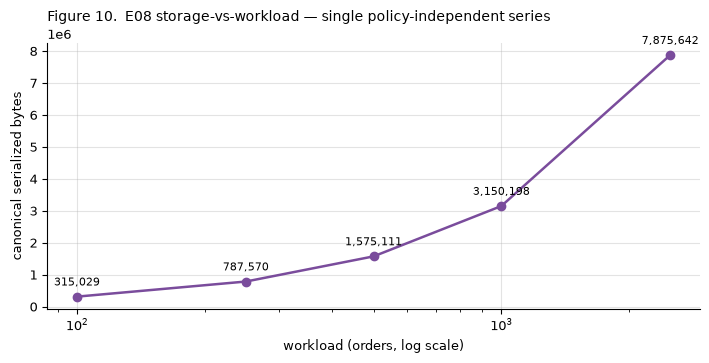

Mean ≈ **3,150 bytes/order** and ≈ **630 bytes/block** (persisted E08 aggregate metrics `bytes_per_order`, `bytes_per_block`). No B0/B1/P storage comparison is made because storage is `POLICY_INDEPENDENT`.

In [18]:
pis = f2["policy_independent_storage"]["per_workload"]
e08_rows = []
for wl in sorted(pis, key=int):
    d = pis[wl]["describe"]
    e08_rows.append({"workload": int(wl), "mean bytes": round(d["mean"], 1),
                     "min": d["min"], "max": d["max"], "n seeds": d["count"]})
e08_df = pd.DataFrame(e08_rows)
display(e08_df)

# single policy-independent series
fig, ax = fig_start(7.2, 3.7)
ax.plot(e08_df["workload"], e08_df["mean bytes"], marker="o", lw=1.8,
        color="#7a4c9c", label="canonical serialized bytes (POLICY_INDEPENDENT)")
for _, r_ in e08_df.iterrows():
    ax.annotate(f"{r_['mean bytes']:,.0f}", (r_["workload"], r_["mean bytes"]),
                xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("workload (orders, log scale)")
ax.set_ylabel("canonical serialized bytes")
ax.set_title("Figure 10.  E08 storage-vs-workload — single policy-independent series", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"Mean ≈ **3,150 bytes/order** and ≈ **630 bytes/block** (persisted E08 aggregate metrics "
"`bytes_per_order`, `bytes_per_block`). No B0/B1/P storage comparison is made because "
"storage is `POLICY_INDEPENDENT`."))

# 17. Throughput — E09

`E09` measures **validated orders per second** (`persisted_validated_orders_per_second`)
for the three policies. Persisted means: `B0 ≈ 26622.492`, `B1 ≈ 4003.845`,
`P ≈ 18016.101`.

,Policy,mean (orders/s),median (orders/s),min (orders/s),max (orders/s),n cells
0,B0,26622.492,26408.379,14941.724,33150.911,15
1,B1,4003.845,4167.242,2791.725,4646.619,15
2,P,18016.101,18293.767,12370.732,22955.213,15


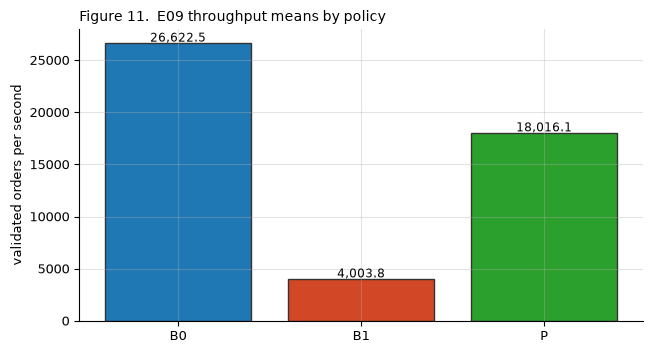

B1 throughput is lower (4,003.8 orders/s) than B0 (26,622.5 orders/s); P sits between them. Throughput is a computational resource proxy, **not** energy. Files: `E09_s*_p*.json` and aggregate `E09.json`.

In [19]:
thr = f2["descriptive_summaries"]["per_policy"]["persisted_validated_orders_per_second"]
thr_rows = []
for p in POLICIES:
    d = thr[p]
    thr_rows.append({
        "Policy": p, "mean (orders/s)": round(d["mean"], 3),
        "median (orders/s)": round(d["median"], 3),
        "min (orders/s)": round(d["min"], 3), "max (orders/s)": round(d["max"], 3),
        "n cells": d["count"],
    })
thr_df = pd.DataFrame(thr_rows)
display(thr_df)

fig, ax = fig_start(6.6, 3.6)
bars = ax.bar(POLICIES, thr_df["mean (orders/s)"],
              color=[POLICY_COLORS[p] for p in POLICIES], edgecolor="#333333")
for b, p in zip(bars, POLICIES):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 150,
            f"{thr_df.loc[POLICIES.index(p), 'mean (orders/s)']:,.1f}", ha="center", fontsize=8.5)
ax.set_ylabel("validated orders per second")
ax.set_title("Figure 11.  E09 throughput means by policy", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

a_, b_ = thr_df.loc[1, "mean (orders/s)"], thr_df.loc[0, "mean (orders/s)"]
display(Markdown(
f"B1 throughput is lower ({a_:,.1f} orders/s) than B0 ({b_:,.1f} orders/s); P sits between them. "
"Throughput is a computational resource proxy, **not** energy. Files: `E09_s*_p*.json` and aggregate `E09.json`."))

# 18. Derived Computational Work — E10

## 18.1 Labelling — `DERIVED_ONLY`

`E10` carries **no independent measurement campaign**. Its values are **derived only**
from re-verified persisted `E06–E09` cell evidence plus deterministic operation
counts (sources: E06, E07, E08, E09). Do **not** treat it as a fourth benchmark.

Expected persisted means: hash operations `B0 = 870`, `B1 = 15,660`, `P = 902.867`;
validation checks `B0 = 3,480`, `B1 = 20,880`, `P = 5,254.8`; validator invocations
`B0 = 870`, `B1 = 2,610`, `P = 873.867`.

,Policy,hash ops mean,validation checks mean,validator invocations mean
0,B0,870.000,3480.0,870.000
1,B1,15660.000,20880.0,2610.000
2,P,902.867,5254.8,873.867


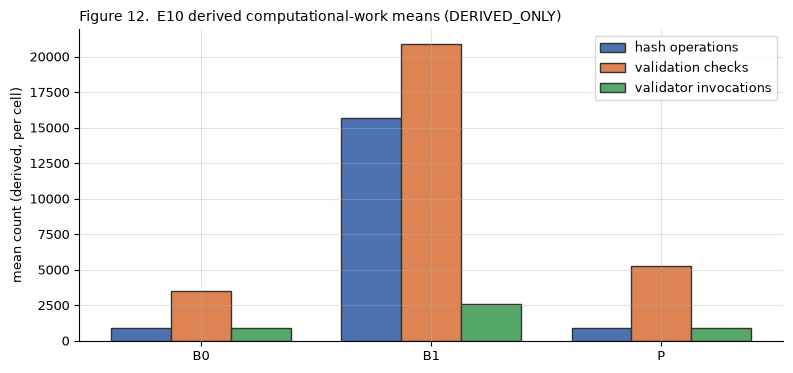

Values confirm the policy contract: B1 applies more checks (c1–c8, 3 validators) and therefore more hash operations; B0 applies fewer (c1–c4, 1 validator); P adapts (MEDIUM band: c1–c6, 1 validator), with a slight upward pull when the few HIGH orders occur. `DERIVED_ONLY` — no new measurement.

In [20]:
e10 = load_json("results/blockchain/v11e/v11e_aggregated_descriptive_summaries/E10.json")["per_policy"]
work_rows = []
for p in POLICIES:
    m = e10[p]["metrics"]
    work_rows.append({"Policy": p,
                      "hash ops mean": round(m["measurable_hash_operation_count"]["mean"], 3),
                      "validation checks mean": round(m["validation_check_count"]["mean"], 3),
                      "validator invocations mean": round(m["validator_invocation_count"]["mean"], 3)})
work_df = pd.DataFrame(work_rows)
display(work_df)

fig, ax = fig_start(8.0, 3.8)
x = np.arange(3); width = 0.26
hx = [work_df.loc[i, "hash ops mean"] for i in range(3)]
cx = [work_df.loc[i, "validation checks mean"] for i in range(3)]
vx = [work_df.loc[i, "validator invocations mean"] for i in range(3)]
ax.bar(x - width, hx, width, label="hash operations", color="#4c72b0", edgecolor="#333333")
ax.bar(x, cx, width, label="validation checks", color="#dd8452", edgecolor="#333333")
ax.bar(x + width, vx, width, label="validator invocations", color="#55a868", edgecolor="#333333")
ax.set_xticks(x); ax.set_xticklabels(POLICIES)
ax.set_ylabel("mean count (derived, per cell)")
ax.legend()
ax.set_title("Figure 12.  E10 derived computational-work means (DERIVED_ONLY)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"Values confirm the policy contract: B1 applies more checks (c1–c8, 3 validators) and therefore "
"more hash operations; B0 applies fewer (c1–c4, 1 validator); P adapts (MEDIUM band: c1–c6, 1 "
"validator), with a slight upward pull when the few HIGH orders occur. `DERIVED_ONLY` — no new "
"measurement."))

# 19. Security–Resource Trade-Off

## 19.1 Endpoint-specific comparison

The table below is **endpoint-specific** (descriptive). No composite score, weighted
score, overall rank, or winner is computed.

In [21]:
trade_rows = []
def _get(family, pol, key="mean"):
    return f2["descriptive_summaries"]["per_policy"][family][pol][key]

for p in POLICIES:
    trade_rows.append({
        "Policy": p,
        "Attack detection (E02, n/135)": f"{det[p]}/135 ({det[p]/135:.3f})",
        "Unaffected orders preserved (E04)": "117315 / 117315",
        "CPU runtime mean (ns)": f"{_get('persisted_cpu_process_timing', p):,.1f}",
        "Wall runtime mean (ns)": f"{_get('persisted_wall_clock_timing', p):,.1f}",
        "Throughput mean (orders/s)": f"{thr[p]['mean']:,.1f}",
        "Hash operations mean (E10)": f"{_get('measurable_hash_operation_count', p):,.1f}",
        "Memory proxy mean (MiB)": f"{e07[p]['metrics']['memory_proxy_mib']['mean']:.6f}",
    })
trade_df = pd.DataFrame(trade_rows)
display(trade_df)

p_cpu_vs_b0 = (_get('persisted_cpu_process_timing', 'P') / _get('persisted_cpu_process_timing', 'B0') - 1) * 100
p_checks_vs_b0 = (_get('validation_check_count', 'P') / _get('validation_check_count', 'B0') - 1) * 100
p_hash_vs_b0 = (_get('measurable_hash_operation_count', 'P') / _get('measurable_hash_operation_count', 'B0') - 1) * 100
p_throughput_below_b0 = (1 - thr['P']['mean'] / thr['B0']['mean']) * 100

display(Markdown(
"**Evidence-based interpretation (endpoint-specific, not a ranking):**\n"
"- **B0**: lowest persisted runtime and computational work and highest throughput, but **lower**"
"  governed attack detection (30/135).\n"
"- **B1**: highest governed detection (105/135), but **greater** persisted computational work/runtime"
"  and **lower** throughput.\n"
f"- **P versus B0**: similar mean hash-operation count (+{p_hash_vs_b0:.1f}%), but higher mean "
f"  validation checks (+{p_checks_vs_b0:.1f}%) and CPU runtime (+{p_cpu_vs_b0:.1f}%), with "
f"  mean throughput {p_throughput_below_b0:.1f}% lower; governed detection is 75/135 versus 30/135.\n"
"- **P versus B1**: substantially lower persisted computational work and runtime, but lower governed "
"  detection (75/135 versus 105/135). P is **not universally superior** on any endpoint aggregate."))

,Policy,"Attack detection (E02, n/135)",Unaffected orders preserved (E04),CPU runtime mean (ns),Wall runtime mean (ns),Throughput mean (orders/s),Hash operations mean (E10),Memory proxy mean (MiB)
0,B0,30/135 (0.222),117315 / 117315,"53,189.4","51,063.6","26,622.5",870.0,1.265201
1,B1,105/135 (0.778),117315 / 117315,"331,166.4","318,159.8","4,003.8","15,660.0",1.265740
2,P,75/135 (0.556),117315 / 117315,"74,081.2","71,100.8","18,016.1",902.9,1.265695


**Evidence-based interpretation (endpoint-specific, not a ranking):**
- **B0**: lowest persisted runtime and computational work and highest throughput, but **lower**  governed attack detection (30/135).
- **B1**: highest governed detection (105/135), but **greater** persisted computational work/runtime  and **lower** throughput.
- **P versus B0**: similar mean hash-operation count (+3.8%), but higher mean   validation checks (+51.0%) and CPU runtime (+39.3%), with   mean throughput 32.3% lower; governed detection is 75/135 versus 30/135.
- **P versus B1**: substantially lower persisted computational work and runtime, but lower governed   detection (75/135 versus 105/135). P is **not universally superior** on any endpoint aggregate.

## 19.2 Endpoint scatter (runtime proxy × detection rate)

This visualization is **endpoint-specific** and is **not** an overall policy ranking.

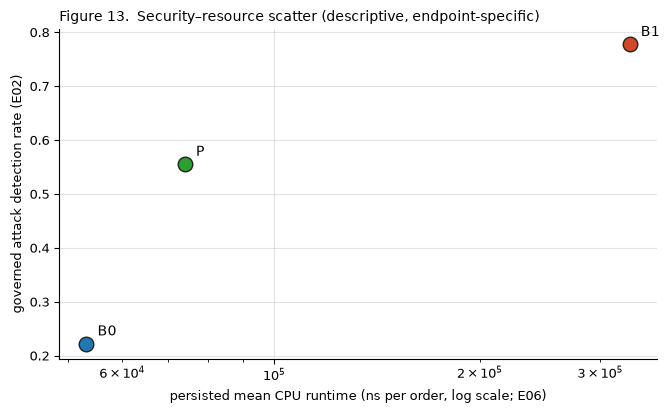

**Caption/reading rule:** the two axes are separate endpoints (E06 runtime proxy vs E02 governed detection); the CPU-runtime x-axis is logarithmic. Distance in this space is not a score; the plot is exploratory and descriptive. There is no overall policy ranking, winner, or composite index.

In [22]:
fig, ax = fig_start(6.8, 4.2)
for p in POLICIES:
    cpu_mean = _get("persisted_cpu_process_timing", p)
    rate = det[p] / den
    ax.scatter(cpu_mean, rate, s=110, color=POLICY_COLORS[p], edgecolor="#222222", zorder=3, label=p)
    ax.annotate(p, (cpu_mean, rate), xytext=(8, 6), textcoords="offset points", fontsize=10)
ax.set_xlabel("persisted mean CPU runtime (ns per order, log scale; E06)")
ax.set_ylabel("governed attack detection rate (E02)")
ax.set_xscale("log")
ax.set_title("Figure 13.  Security–resource scatter (descriptive, endpoint-specific)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

display(Markdown(
"**Caption/reading rule:** the two axes are separate endpoints (E06 runtime proxy vs E02 governed "
"detection); the CPU-runtime x-axis is logarithmic. Distance in this space is not a score; "
"the plot is exploratory and descriptive. "
"There is no overall policy ranking, winner, or composite index."))

# 20. Green-Oriented Interpretation

## 20.1 Status: `DIRECT_ENERGY_UNAVAILABLE`

This study provides **computational/resource-efficiency evidence relevant to
green-oriented blockchain evaluation**, not direct energy-consumption measurements.

### Allowed terminology (used here)
- resource efficiency · computational efficiency · green-oriented evaluation ·
  lightweight computational profile · computational proxies relevant to green evaluation.

### Explicitly NOT claimed
No **energy savings**, **energy reduction**, **measured energy efficiency**,
**Joules/Watts saved**, **power reduction**, **carbon/CO₂ reduction**, or any
TDP×time-derived energy quantity appears anywhere in this notebook.

### Why this matters
Persisted CPU/wall times are runtime proxies; the tracemalloc peak is a Python
memory proxy; storage bytes and throughput are structural/operational descriptors.
None of these is a physical electrical-energy measurement, so no claim that depends
on one is made. Direct energy measurement would require a separate, separately
governed experiment (`future_direct_measurement_requires_separate_governance = true`).

# 21. Experimental Limitations

The governed evidence must be interpreted **only** under the following frozen
limitations:

1. `DIRECT_ENERGY_UNAVAILABLE` — no physical electrical-energy quantity measured.
2. E07 is a `COMPUTATIONAL_MEMORY_PROXY` (fresh-process Python `tracemalloc` peak), not RSS/system memory.
3. E08 is `POLICY_INDEPENDENT` (canonical serialized bytes); its B0 token is a serialization placeholder.
4. E10 is `DERIVED_ONLY` (from E06–E09), not an independent campaign.
5. E03 is **not** independent confirmatory evidence — it mirrors E02 detection by construction.
6. LOW band is **absent** from the governed population.
7. HIGH band is **sparse** (6 / 4,588) and descriptive-only.
8. HIGH is **absent at workload 100** (`HIGH_NOT_OBSERVED_IN_CONDITION`).
9. Workload sizes are **nested** within each seed and are **not** independent replicates.
10. Only **three fixed seeds** (522–524) — no broad sampling distribution.
11. Analysis is **descriptive only** — no p-values, confidence intervals, or bootstrap.
12. Evidence is tied to the governed design/environment (single machine, one warmup, validation-policy timing boundary).
13. There is **no universal policy winner**; all interpretations are endpoint-specific.
14. Synthetic tampering is a laboratory scenario on generated copies, disclosed as such.

These limitations are the frozen scientific stance of `V1.1-F` and are preserved
verbatim in spirit from `v11f_analysis_results.json` (`scientific_limitations`) and
the F5 closure.

# 22. Reproducibility and Frozen Evidence

Every scientific value in this notebook descends from locked artifacts. The table
below reports the frozen identifiers required by the V1.1-G1 gate and their
verification status, recomputed live (no lock is modified).

In [23]:
repro_rows = [
    ("Repository HEAD", "a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981", git_head("HEAD"), "", "git commit"),
    ("F2 semantic (persisted pin) — v11f_analysis_results.json",
     EXPECTED_HASHES["F2 semantic"], f2.get("semantic_analysis_sha256"), "", "analysis payload"),
    ("F4 analysis artifact file SHA - v11f_analysis_results.json",
     EXPECTED_HASHES["F4 analysis file"], file_sha256("results/blockchain/v11f/v11f_analysis_results.json"), "", "file SHA-256"),
    ("F4 execution manifest file SHA - v11f_execution_manifest.json",
     EXPECTED_HASHES["F4 execution manifest"], file_sha256("results/blockchain/v11f/v11f_execution_manifest.json"), "", "file SHA-256"),
    ("F4 semantic result lock - v11f_result_lock.json",
     EXPECTED_HASHES["F4 semantic result lock"], semantic_sha256("results/blockchain/v11f/v11f_result_lock.json"), "", "semantic lock"),
    ("F5 report file SHA - docs/v11f_resource_efficiency_results.md",
     EXPECTED_HASHES["F5 report"], file_sha256("docs/v11f_resource_efficiency_results.md"), "", "file SHA-256"),
    ("F5 semantic validation - v11f5_validation.json",
     EXPECTED_HASHES["F5 semantic validation"], f5.get("semantic_validation_sha256"), "", "validation closure"),
    ("V1.1-E result-lock file SHA - v11e_experiment_result_lock.json",
     EXPECTED_HASHES["V1.1-E result-lock file"], file_sha256("results/blockchain/v11e/v11e_experiment_result_lock.json"), "", "file SHA-256"),
    ("V1.1-E semantic result lock",
     EXPECTED_HASHES["V1.1-E semantic"], semantic_sha256("results/blockchain/v11e/v11e_experiment_result_lock.json"), "", "semantic lock"),
    ("validation_gates_all", "true", f5.get("validation_gates_all"), "", "validation closure"),
]
repro = []
for name, expected, actual, extra, kind in repro_rows:
    ok = str(expected).lower() == str(actual).lower()
    repro.append({"Artifact / identifier": name, "Purpose": kind,
                  "Expected": str(expected), "Verified": str(actual),
                  "Status": "PASS" if ok else "FAIL"})
repro_df = pd.DataFrame(repro)
display(repro_df)

gates = f5.get("validation_gates", {})
gates_ok = sum(1 for v in gates.values() if v is True)
print(f"validation_gates: {gates_ok}/{len(gates)} true;  validation_gates_all = {f5.get('validation_gates_all')}")

,Artifact / identifier,Purpose,Expected,Verified,Status
0,Repository HEAD,git commit,a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981,a9bbc2ce46b7b4773c00853cfd3a030bc3c2b981,PASS
1,F2 semantic (persisted pin) — v11f_analysis_re...,analysis payload,0765ea4d79cdad956d09156983395c9c85fe748002cd91...,0765ea4d79cdad956d09156983395c9c85fe748002cd91...,PASS
2,F4 analysis artifact file SHA - v11f_analysis_...,file SHA-256,eb4ce1c69d56385a0bddc606bed40ec4d9dcc049e77a17...,eb4ce1c69d56385a0bddc606bed40ec4d9dcc049e77a17...,PASS
3,F4 execution manifest file SHA - v11f_executio...,file SHA-256,d1fb42d0bfb8b11267fc6572c2c333d7d77ca1b559533e...,d1fb42d0bfb8b11267fc6572c2c333d7d77ca1b559533e...,PASS
4,F4 semantic result lock - v11f_result_lock.json,semantic lock,d639be8970bd6662ed0efe688ec2c0375414942ebf636d...,d639be8970bd6662ed0efe688ec2c0375414942ebf636d...,PASS
5,F5 report file SHA - docs/v11f_resource_effici...,file SHA-256,8afcd5299b21eea2d09bc653bacfac1ca21f76884eb3ae...,8afcd5299b21eea2d09bc653bacfac1ca21f76884eb3ae...,PASS
6,F5 semantic validation - v11f5_validation.json,validation closure,b0fe2451107463f51fdfdd6b8d12bb01356d3ed5c92add...,b0fe2451107463f51fdfdd6b8d12bb01356d3ed5c92add...,PASS
7,V1.1-E result-lock file SHA - v11e_experiment_...,file SHA-256,dd3b926eb08206f505e739ed61c5f29a3e7f03a370e9af...,dd3b926eb08206f505e739ed61c5f29a3e7f03a370e9af...,PASS
8,V1.1-E semantic result lock,semantic lock,058aeca8ac97101356bcf1c4dc5b74fb3affbda6833a85...,058aeca8ac97101356bcf1c4dc5b74fb3affbda6833a85...,PASS
9,validation_gates_all,validation closure,true,True,PASS


validation_gates: 18/18 true;  validation_gates_all = True


# 23. Thesis-Ready Conclusions

Within the frozen `V1.1` governed scope (real governed orders; seeds 522–524; nested
workloads 100–2500; policies B0/B1/P; PA-01…PA-09 tamper scenarios; descriptive-only
analysis), the evidence supports the following **endpoint-specific** statements:

1. **Integrity layer mechanism.** The deterministic per-order hash-linked ledger and
   its `c1–c8` verification reproduce and verify real order chains; V1.1-C validated
   25,881 such chains, and E01 reports `13050/13050` clean verification passes per
   policy with zero false rejections.

2. **Detection.** Governed attack detection is policy-dependent: `B1 = 105/135`,
   `P = 75/135`, `B0 = 30/135`. P detects more governed attacks than B0 while
   applying notably less computational work than B1.

3. **Localization & isolation.** Localization outcomes mirror detection (E03 is not
   independent confirmatory evidence); unaffected-order preservation is
   `117315/117315` per policy with zero cross-order propagation (E04).

4. **Adaptive policy P.** P allocates validation strictly by the governed risk band —
   6 checks/1 validator for MEDIUM, 8 checks/3 validators for the few HIGH orders,
   and no LOW-band observations exist in the governed population (E05).

5. **Resource-efficiency profile.** B1 shows several-fold greater mean CPU runtime than
   B0 and P (≈ 6.226× and ≈ 4.470× respectively; means ≈ 331,166 vs ≈ 53,189 / 74,081 ns); throughput follows the
   inverse pattern (B0 ≈ 26,622 orders/s > P ≈ 18,016 > B1 ≈ 4,003). Memory proxies
   are descriptively near-identical (≈ 1.265 MiB) and storage is policy-independent
   (≈ 3,150 bytes/order) — both `COMPUTATIONAL_MEMORY_PROXY`/`POLICY_INDEPENDENT`.

6. **No energy claim.** All of the above are computational proxies under
   `DIRECT_ENERGY_UNAVAILABLE`; direct energy measurement would require separate
   governance.

7. **No ranking.** These are endpoint-specific observations; there is no overall
   winner, no composite score, and no global ordering of B0/B1/P.

**Bottom line (descriptive, governed scope):** adaptive policy P occupies an
intermediate, risk-aware position on the governed endpoints — greater attack coverage
than B0 while showing higher persisted validation work and runtime and lower throughput;
relative to B1, P shows substantially lower persisted work/runtime but lower detection —
without any claim of
universal superiority and without any direct energy measurement.